In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import warnings
import textwrap
import matplotlib.pyplot as plt

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_core.tools import tool

from dotenv import load_dotenv
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")  
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

import warnings
warnings.filterwarnings('ignore')

In [3]:
data_dir = "Data"
datasets = {}

for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        datasets[name] = pd.read_csv(os.path.join(data_dir, file))

In [4]:
metadata = {
    "provider": "Provider billing dataset with charges, services, demographics.",
    "claims": "Claims dataset with vehicle, policy and claim status.",
    "marketing": "Customer marketing and spend dataset."
}


In [5]:
dataset_selector_prompt = PromptTemplate(
    input_variables=["query", "metadata"],
    template="""
You are a dataset selection assistant.
You have access to the following datasets:{metadata}
The user asked:'{query}'
Which dataset(s) contain the columns needed to answer the question?
Return ONLY a comma-separated list of dataset names with no explanation.
"""
)

In [6]:
def select_datasets(chat_client, query, metadata):
    metadata_text = "\n".join([f"{k}: {v}" for k, v in metadata.items()])
    prompt = dataset_selector_prompt.format(query=query, metadata=metadata_text)
    response = chat_client.invoke(prompt)

    selected = [
        ds.strip()
        for ds in response.content.split(",")
        if ds.strip() in metadata.keys()
    ]

    return selected

In [14]:
import textwrap

def python_plotter(code: str):
    """
    Execute LLM-generated Python code and ONLY display the graph.
    """
    global df

    # ✅ CRITICAL FIX: decode escaped characters
    cleaned = code.encode("utf-8").decode("unicode_escape")

    # Optional cleanup
    cleaned = cleaned.strip()
    cleaned = textwrap.dedent(cleaned)

    print("Executing Python code:\n", cleaned)  # Debug

    try:
        exec(cleaned, globals())
    except Exception as e:
        print("ERROR executing code:\n", cleaned)
        raise e

    return ""


In [15]:
GRAPH_SYSTEM_PROMPT = """
You are a data visualization expert.

Your job is to ALWAYS generate a graph from the dataframe `df`.

RULES:
1. Determine the analytical intent:
   - Comparison or Ranking  → bar chart
   - Trend over time        → line chart
   - Distribution           → histogram
   - Relationship           → scatter plot

2. You MUST select the most appropriate graph type automatically.

3. You MUST output ONLY valid Python code that:
   - Uses the dataframe `df`
   - Uses ONLY column names that exist in df
   - Produces a matplotlib graph
   - Labels axes and title clearly
   - Calls plt.show() at the end

4. You MUST NOT output anything except the Python code.
5. NO explanations.
6. NO markdown.
7. NO commentary.
"""

In [16]:
graph_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

graph_agent = graph_llm.bind_tools([python_plotter])


In [17]:
def answer_with_graph(query):

    selected = select_datasets(graph_llm, query, metadata)

    if not selected:
        return "No dataset contains the required fields."

    df_name = selected[0]
    df = datasets[df_name]
    globals()["df"] = df  


    schema_text = "\n".join([f"- {col}" for col in df.columns])

    messages = [
        ("system", GRAPH_SYSTEM_PROMPT + f"\n\nThe dataframe has these columns:\n{schema_text}"),
        ("user", query)
    ]

  
    response = graph_agent.invoke(messages)


    if hasattr(response, "tool_calls"):
        for call in response.tool_calls:
            if call["name"] == "python_plotter":
                code = call["args"]["code"]
                return python_plotter(code)


    return ""

Executing Python code:
 import matplotlib.pyplot as plt
df_top_providers = df.nlargest(10, 'Tot_Sbmtd_Chrg')
plt.barh(df_top_providers['Rndrng_Prvdr_Last_Org_Name'], df_top_providers['Tot_Sbmtd_Chrg'], color='skyblue')
plt.xlabel('Total Submitted Charges')
plt.ylabel('Provider Name')
plt.title('Top 10 Providers with Highest Total Submitted Charges')
plt.show()


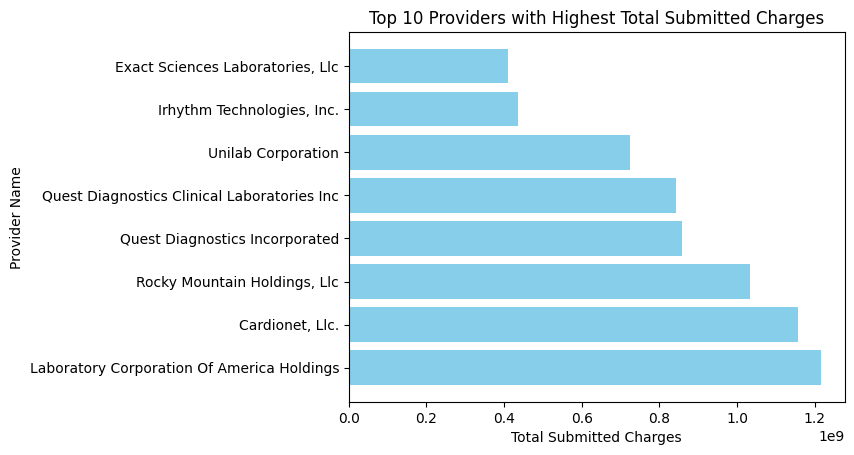

''

In [18]:
query = "Who are the top 10 providers with the highest total submitted charges?"

answer_with_graph(query)
